In [4]:
!pip install torchmetrics thop

In [15]:
%%writefile conv1.py
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import numpy as np
from tqdm import tqdm
import json

# New imports for metrics
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from thop import profile
except ImportError:
    print("Please install required libraries: pip install torchmetrics thop")
    exit()


# 1. Model Definitions (Standard DCGAN)

class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            self._block(z_dim, features_g * 16, 4, 1, 0),  # 4x4
            self._block(features_g * 16, features_g * 8, 4, 2, 1),  # 8x8
            self._block(features_g * 8, features_g * 4, 4, 2, 1),  # 16x16
            self._block(features_g * 4, features_g * 2, 4, 2, 1),  # 32x32
            nn.ConvTranspose2d(features_g * 2, channels_img, 4, 2, 1), # 64x64
            nn.Tanh(),
        )

    def _block(self, in_c, out_c, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.gen(x)

class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            nn.Conv2d(channels_img, features_d, 4, 2, 1), # 32x32
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1), # 16x16
            self._block(features_d * 2, features_d * 4, 4, 2, 1), # 8x8
            self._block(features_d * 4, features_d * 8, 4, 2, 1), # 4x4
            nn.Conv2d(features_d * 8, 1, 4, 2, 0), # 1x1
        )

    def _block(self, in_c, out_c, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel, stride, padding, bias=False),
            # InstanceNorm is often more stable than BatchNorm for Discriminators
            nn.InstanceNorm2d(out_c, affine=True), 
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.disc(x)

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

# 2. Dataset Definition

class BanglaDigitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Root dir not found: {root_dir}")

        # Try organized folders first
        for label in range(10):
            label_dir = os.path.join(root_dir, str(label))
            if os.path.isdir(label_dir):
                for img_name in os.listdir(label_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(label_dir, img_name))
        
        # Fallback to recursive search if structure is different
        if len(self.image_paths) == 0:
            self.image_paths = glob.glob(os.path.join(root_dir, '**', '*.jpg'), recursive=True) + \
                               glob.glob(os.path.join(root_dir, '**', '*.png'), recursive=True)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"FATAL: No images found in {root_dir}!")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('L')
            if self.transform:
                image = self.transform(image)
            return image, 0
        except Exception:
            return torch.zeros((1, 64, 64)), 0


# 3. Helper Functions (FLOPs & Params)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_flops(model, input_shape, device):
    """Safely calculates FLOPs on a dummy copy to avoid DDP hooks issues."""
    try:
        dummy_input = torch.randn(1, *input_shape).to(device)
        # Deep copy or re-instantiate is preferred, here we assume model is fresh
        macs, params = profile(model, inputs=(dummy_input, ), verbose=False)
        return macs * 2  # Approx FLOPs
    except Exception as e:
        return 0


# 4. Training Function

def train_fn(rank, world_size, hp):
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)
    
    if rank == 0:
        os.makedirs("outputs", exist_ok=True)
        os.makedirs("checkpoints", exist_ok=True)
    
    transform = transforms.Compose([
        transforms.Resize((hp['IMAGE_SIZE'], hp['IMAGE_SIZE'])),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    
    # Dataset loading logic
    possible_paths = [
        "/kaggle/input/bengali-digits/bengali_digits",
        "/kaggle/input/bengali-digits",
        "./bengali_digits"
    ]
    
    dataset = None
    for path in possible_paths:
        if os.path.exists(path):
            try:
                dataset = BanglaDigitDataset(root_dir=path, transform=transform)
                if len(dataset) > 0:
                    if rank == 0: 
                        print(f"✓ Loaded {len(dataset)} images from: {path}")
                    break
            except Exception:
                continue
    
    if dataset is None or len(dataset) == 0:
        if rank == 0: 
            print("ERROR: No valid dataset found!")
        destroy_process_group()
        return

    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    dataloader = DataLoader(
        dataset, 
        batch_size=hp['BATCH_SIZE'], 
        shuffle=False, 
        sampler=sampler,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    #  Metrics Setup (Rank 0 only to avoid clutter) 
    metrics_log = {
        "config": hp,
        "model_stats": {},
        "epochs": []
    }

    #  Pre-DDP FLOPs Calculation (Safe Mode) 
    # We calculate FLOPs/Params on Rank 0 using dummy models BEFORE wrapping in DDP
    # This prevents 'thop' hooks from crashing DDP synchronization
    if rank == 0:
        dummy_gen = Generator(hp['NOISE_DIM'], hp['CHANNELS_IMG'], hp['FEATURES_GEN']).to(rank)
        dummy_disc = Discriminator(hp['CHANNELS_IMG'], hp['FEATURES_DISC']).to(rank)
        
        g_params = count_parameters(dummy_gen)
        d_params = count_parameters(dummy_disc)
        
        g_flops = get_flops(dummy_gen, (hp['NOISE_DIM'], 1, 1), rank)
        d_flops = get_flops(dummy_disc, (hp['CHANNELS_IMG'], hp['IMAGE_SIZE'], hp['IMAGE_SIZE']), rank)
        
        # Scale FLOPs to entire epoch
        g_flops_epoch = g_flops * len(dataset)
        d_flops_epoch = d_flops * len(dataset)

        metrics_log["model_stats"] = {
            "gen_params": g_params,
            "disc_params": d_params,
            "gen_flops_per_sample": g_flops,
            "disc_flops_per_sample": d_flops,
            "est_gen_flops_epoch_T": g_flops_epoch / 1e12, # TeraFLOPs
            "est_disc_flops_epoch_T": d_flops_epoch / 1e12
        }
        
        print(f"ℹ️ Gen Params: {g_params:,} | FLOPs/Ep: {g_flops_epoch/1e12:.4f} T")
        print(f"ℹ️ Disc Params: {d_params:,} | FLOPs/Ep: {d_flops_epoch/1e12:.4f} T")
        
        del dummy_gen, dummy_disc
        torch.cuda.empty_cache()

    # Initialize models for training
    gen = Generator(hp['NOISE_DIM'], hp['CHANNELS_IMG'], hp['FEATURES_GEN']).to(rank)
    disc = Discriminator(hp['CHANNELS_IMG'], hp['FEATURES_DISC']).to(rank)
    
    gen.apply(initialize_weights)
    disc.apply(initialize_weights)

    # Wrap in DDP
    gen = DDP(gen, device_ids=[rank])
    disc = DDP(disc, device_ids=[rank])

    # Optimizers
    opt_gen = optim.Adam(gen.parameters(), lr=hp['LEARNING_RATE_G'], betas=(hp['BETA_1'], hp['BETA_2']))
    opt_disc = optim.Adam(disc.parameters(), lr=hp['LEARNING_RATE_D'], betas=(hp['BETA_1'], hp['BETA_2']))
    
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler('cuda')
    fixed_noise = torch.randn(32, hp['NOISE_DIM'], 1, 1).to(rank)
    
    # FID Metric (Using feature=64 for faster calculation during training)
    fid_metric = FrechetInceptionDistance(feature=64, normalize=True).to(rank)

    if rank == 0:
        print(f"🚀 Training: {world_size} GPUs | Batch: {hp['BATCH_SIZE']}/GPU")

    
    # 5. Training Loop
    
    for epoch in range(hp['NUM_EPOCHS']):
        sampler.set_epoch(epoch)
        
        iterator = tqdm(dataloader, desc=f"Epoch {epoch+1}/{hp['NUM_EPOCHS']}", disable=(rank != 0))
        
        epoch_loss_d = []
        epoch_loss_g = []
        
        # Reset FID for this epoch
        fid_metric.reset()
        
        for batch_idx, (real, _) in enumerate(iterator):
            real = real.to(rank, non_blocking=True)
            curr_batch_size = real.shape[0]
            
            #  Train Discriminator 
            with torch.amp.autocast('cuda'):
                noise = torch.randn(curr_batch_size, hp['NOISE_DIM'], 1, 1).to(rank)
                fake = gen(noise)
                disc_real = disc(real).reshape(-1)
                
                # Label Smoothing
                real_labels = torch.rand(curr_batch_size, device=rank) * 0.1 + 0.9 
                fake_labels = torch.rand(curr_batch_size, device=rank) * 0.1      
                
                loss_disc_real = criterion(disc_real, real_labels)
                disc_fake = disc(fake.detach()).reshape(-1) 
                loss_disc_fake = criterion(disc_fake, fake_labels)
                loss_disc = (loss_disc_real + loss_disc_fake) / 2

            opt_disc.zero_grad(set_to_none=True)
            scaler.scale(loss_disc).backward()
            scaler.step(opt_disc)
            
            epoch_loss_d.append(loss_disc.item())

            #  Train Generator 
            with torch.amp.autocast('cuda'):
                output = disc(fake).reshape(-1)
                loss_gen = criterion(output, torch.ones_like(output))

            opt_gen.zero_grad(set_to_none=True)
            scaler.scale(loss_gen).backward()
            scaler.step(opt_gen)
            scaler.update()
            
            epoch_loss_g.append(loss_gen.item())

            if rank == 0 and batch_idx % 10 == 0:
                iterator.set_postfix(D=f"{loss_disc.item():.3f}", G=f"{loss_gen.item():.3f}")

            #  Update FID Statistics (Batch-wise) 
            # FID needs uint8 [0,255] or float [0,1]. Real is [-1,1].
            # Also needs 3 channels, so we repeat.
            with torch.no_grad():
                # Real
                real_rgb = real.repeat(1, 3, 1, 1)
                real_rgb = (real_rgb * 0.5 + 0.5).clamp(0, 1)
                fid_metric.update(real_rgb, real=True)
                
                # Fake (Create new batch to not mess with graphs)
                if batch_idx % 5 == 0: # Update FID every 5th batch to save time
                    fake_rgb = fake.detach().repeat(1, 3, 1, 1)
                    fake_rgb = (fake_rgb * 0.5 + 0.5).clamp(0, 1)
                    fid_metric.update(fake_rgb, real=False)

        #  End of Epoch Aggregation 
        # 1. Compute FID
        fid_score = fid_metric.compute().item()
        
        # 2. Compute Memory Usage
        gpu_mem_alloc = torch.cuda.memory_allocated(rank) / 1024**3 # GB
        gpu_mem_res = torch.cuda.memory_reserved(rank) / 1024**3    # GB

        if rank == 0:
            avg_loss_d = np.mean(epoch_loss_d)
            avg_loss_g = np.mean(epoch_loss_g)
            
            print(f"✓ Epoch {epoch+1} | D: {avg_loss_d:.4f} | G: {avg_loss_g:.4f} | FID: {fid_score:.2f} | MEM: {gpu_mem_res:.2f}GB")
            
            # Log Metrics
            log_entry = {
                "epoch": epoch + 1,
                "loss_disc": float(avg_loss_d),
                "loss_gen": float(avg_loss_g),
                "fid_score": float(fid_score),
                "gpu_mem_reserved_gb": float(gpu_mem_res),
                "gpu_mem_allocated_gb": float(gpu_mem_alloc)
            }
            metrics_log["epochs"].append(log_entry)

            # Save Images
            with torch.no_grad():
                fake_viz = gen(fixed_noise)
                vutils.save_image(fake_viz[:25], f"outputs/epoch_{epoch+1:02d}_fid{fid_score:.1f}.png", nrow=5, normalize=True)
            
            # Save Checkpoint
            if (epoch + 1) % 10 == 0:
                torch.save({
                    'epoch': epoch + 1,
                    'generator_state_dict': gen.module.state_dict(),
                    'discriminator_state_dict': disc.module.state_dict(),
                    'metrics': metrics_log
                }, f"checkpoints/checkpoint_epoch_{epoch+1:02d}.pth")
                print(f"💾 Checkpoint saved")

    # Save final logs and models
    if rank == 0:
        torch.save(gen.module.state_dict(), "checkpoints/generator_final.pth")
        torch.save(disc.module.state_dict(), "checkpoints/discriminator_final.pth")
        
        with open("checkpoints/training_metrics.json", "w") as f:
            json.dump(metrics_log, f, indent=4)
        
        print("✅ Training complete! Metrics saved to checkpoints/training_metrics.json")

    destroy_process_group()


# 6. Main Entry Point

if __name__ == '__main__':
    hyperparameters = {
        'LEARNING_RATE_G': 2e-4,     # Standard DCGAN LR
        'LEARNING_RATE_D': 2e-4,     # Equalized!
        'BATCH_SIZE': 128,           # Smaller batch per GPU for better generalization
        'IMAGE_SIZE': 64,
        'CHANNELS_IMG': 1,
        'NOISE_DIM': 100,
        'FEATURES_DISC': 64,
        'FEATURES_GEN': 64,
        'NUM_EPOCHS': 50,
        'BETA_1': 0.5,
        'BETA_2': 0.999
    }
    
    world_size = torch.cuda.device_count()
    if world_size > 1:
        mp.spawn(train_fn, args=(world_size, hyperparameters), nprocs=world_size)
    else:
        train_fn(0, 1, hyperparameters)

Overwriting conv1.py


In [16]:
!python conv1.py

✓ Loaded 15620 images from: /kaggle/input/bengali-digits/bengali_digits
ℹ️ Gen Params: 12,654,337 | FLOPs/Ep: 51.4273 T
ℹ️ Disc Params: 2,763,585 | FLOPs/Ep: 3.1849 T
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|███████████████████████████████████████| 91.2M/91.2M [00:00<00:00, 259MB/s]
100%|██████████████████████████████████████| 91.2M/91.2M [00:01<00:00, 57.8MB/s]
🚀 Training: 2 GPUs | Batch: 128/GPU
Epoch 1/50: 100%|█████████████| 62/62 [00:38<00:00,  1.60it/s, D=0.291, G=1.933]
/usr/local/lib/python3.12/dist-packages/torch/distributed/distributed_c10d.py:4807: UserWarning: No device id is provided via `init_process_group` o

In [27]:
%%writefile depthwise.py
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import numpy as np
from tqdm import tqdm
import json

#  New Imports for Metrics 
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from thop import profile
except ImportError:
    print("Please install required libraries: pip install torchmetrics thop")
    exit()


# 1. Model Definitions (Depthwise Separable - RESTORED)

class DepthwiseSeparableConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, bias=False):
        super().__init__()
        # Depthwise: Groups = in_c (each channel convolved independently)
        self.depthwise = nn.Conv2d(in_c, in_c, k, s, p, groups=in_c, bias=bias)
        # Pointwise: Mixes channels
        self.pointwise = nn.Conv2d(in_c, out_c, 1, 1, 0, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class DepthwiseSeparableConvTranspose2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, bias=False):
        super().__init__()
        # Depthwise Transpose
        self.depthwise = nn.ConvTranspose2d(in_c, in_c, k, s, p, groups=in_c, bias=bias)
        # Pointwise
        self.pointwise = nn.Conv2d(in_c, out_c, 1, 1, 0, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super().__init__()
        self.gen = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            self._block(z_dim, features_g * 16, 4, 1, 0),  # 4x4
            self._block(features_g * 16, features_g * 8, 4, 2, 1),  # 8x8
            self._block(features_g * 8, features_g * 4, 4, 2, 1),  # 16x16
            self._block(features_g * 4, features_g * 2, 4, 2, 1),  # 32x32
            # Final Layer
            DepthwiseSeparableConvTranspose2d(features_g * 2, channels_img, 4, 2, 1, bias=False), # 64x64
            nn.Tanh(),
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            DepthwiseSeparableConvTranspose2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.gen(x)

class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super().__init__()
        self.disc = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            DepthwiseSeparableConv2d(channels_img, features_d, 4, 2, 1, bias=False), # 32x32
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1), # 16x16
            self._block(features_d * 2, features_d * 4, 4, 2, 1), # 8x8
            self._block(features_d * 4, features_d * 8, 4, 2, 1), # 4x4
            # Final Layer
            DepthwiseSeparableConv2d(features_d * 8, 1, 4, 2, 0, bias=False), # 1x1
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            DepthwiseSeparableConv2d(in_c, out_c, k, s, p, bias=False),
            # InstanceNorm is CRITICAL for lightweight/depthwise stability
            nn.InstanceNorm2d(out_c, affine=True), 
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.disc(x)

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)


# 2. Dataset Definition

class BanglaDigitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Root dir not found: {root_dir}")

        for label in range(10):
            label_dir = os.path.join(root_dir, str(label))
            if os.path.isdir(label_dir):
                for img_name in os.listdir(label_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(label_dir, img_name))
        
        if len(self.image_paths) == 0:
            self.image_paths = glob.glob(os.path.join(root_dir, '**', '*.jpg'), recursive=True) + \
                               glob.glob(os.path.join(root_dir, '**', '*.png'), recursive=True)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"FATAL: No images found in {root_dir}!")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('L')
            if self.transform:
                image = self.transform(image)
            return image, 0
        except Exception:
            return torch.zeros((1, 64, 64)), 0


# 3. Helper Functions (Metrics)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_flops(model, input_shape, device):
    """Safely calculates FLOPs on a dummy copy to avoid DDP hooks issues."""
    try:
        dummy_input = torch.randn(1, *input_shape).to(device)
        macs, params = profile(model, inputs=(dummy_input, ), verbose=False)
        return macs * 2  # Approx FLOPs
    except Exception as e:
        return 0


# 4. Training Function

def train_fn(rank, world_size, hp):
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)
    
    if rank == 0:
        os.makedirs("outputs", exist_ok=True)
        os.makedirs("checkpoints", exist_ok=True)
    
    transform = transforms.Compose([
        transforms.Resize((hp['IMAGE_SIZE'], hp['IMAGE_SIZE'])),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    
    possible_paths = [
        "/kaggle/input/bengali-digits/bengali_digits",
        "/kaggle/input/bengali-digits",
        "./bengali_digits"
    ]
    
    dataset = None
    for path in possible_paths:
        if os.path.exists(path):
            try:
                dataset = BanglaDigitDataset(root_dir=path, transform=transform)
                if len(dataset) > 0:
                    if rank == 0: print(f"✓ Loaded {len(dataset)} images from: {path}")
                    break
            except Exception:
                continue
    
    if dataset is None or len(dataset) == 0:
        if rank == 0: print("ERROR: No valid dataset found!")
        destroy_process_group()
        return

    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    dataloader = DataLoader(
        dataset, batch_size=hp['BATCH_SIZE'], shuffle=False, 
        sampler=sampler, num_workers=4, pin_memory=True, persistent_workers=True
    )

    #  Pre-DDP FLOPs & Params (Safe Mode) 
    metrics_log = {
        "config": hp,
        "model_stats": {},
        "epochs": []
    }
    
    if rank == 0:
        # Create dummy models for profiling
        dummy_gen = Generator(hp['NOISE_DIM'], hp['CHANNELS_IMG'], hp['FEATURES_GEN']).to(rank)
        dummy_disc = Discriminator(hp['CHANNELS_IMG'], hp['FEATURES_DISC']).to(rank)
        
        g_params = count_parameters(dummy_gen)
        d_params = count_parameters(dummy_disc)
        
        g_flops = get_flops(dummy_gen, (hp['NOISE_DIM'], 1, 1), rank)
        d_flops = get_flops(dummy_disc, (hp['CHANNELS_IMG'], hp['IMAGE_SIZE'], hp['IMAGE_SIZE']), rank)
        
        # Scale to epoch
        g_flops_epoch = g_flops * len(dataset)
        d_flops_epoch = d_flops * len(dataset)
        
        metrics_log["model_stats"] = {
            "gen_params": g_params,
            "disc_params": d_params,
            "gen_flops_per_sample": g_flops,
            "disc_flops_per_sample": d_flops,
            "est_gen_flops_epoch_T": g_flops_epoch / 1e12,
            "est_disc_flops_epoch_T": d_flops_epoch / 1e12
        }
        
        print(f"ℹ️ DEPTHWISE Gen Params: {g_params:,} | FLOPs/Ep: {g_flops_epoch/1e12:.4f} T")
        print(f"ℹ️ DEPTHWISE Disc Params: {d_params:,} | FLOPs/Ep: {d_flops_epoch/1e12:.4f} T")
        
        del dummy_gen, dummy_disc
        torch.cuda.empty_cache()

    # Initialize Real Models
    gen = Generator(hp['NOISE_DIM'], hp['CHANNELS_IMG'], hp['FEATURES_GEN']).to(rank)
    disc = Discriminator(hp['CHANNELS_IMG'], hp['FEATURES_DISC']).to(rank)
    
    gen.apply(initialize_weights)
    disc.apply(initialize_weights)

    gen = DDP(gen, device_ids=[rank])
    disc = DDP(disc, device_ids=[rank])

    # Optimizers
    opt_gen = optim.Adam(gen.parameters(), lr=hp['LEARNING_RATE_G'], betas=(hp['BETA_1'], hp['BETA_2']))
    opt_disc = optim.Adam(disc.parameters(), lr=hp['LEARNING_RATE_D'], betas=(hp['BETA_1'], hp['BETA_2']))
    
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler('cuda')
    fixed_noise = torch.randn(32, hp['NOISE_DIM'], 1, 1).to(rank)
    
    # FID Setup
    fid_metric = FrechetInceptionDistance(feature=64, normalize=True).to(rank)
    
    if rank == 0:
        print(f"🚀 Training Depthwise GAN: {world_size} GPUs | Batch: {hp['BATCH_SIZE']}/GPU")

    
    # 5. Training Loop
    
    for epoch in range(hp['NUM_EPOCHS']):
        sampler.set_epoch(epoch)
        iterator = tqdm(dataloader, desc=f"Ep {epoch+1}/{hp['NUM_EPOCHS']}", disable=(rank != 0))
        
        epoch_loss_d = []
        epoch_loss_g = []
        
        # Reset metrics for new epoch
        fid_metric.reset()
        
        for batch_idx, (real, _) in enumerate(iterator):
            real = real.to(rank, non_blocking=True)
            curr_batch_size = real.shape[0]
            
            #  Train Discriminator 
            with torch.amp.autocast('cuda'):
                noise = torch.randn(curr_batch_size, hp['NOISE_DIM'], 1, 1).to(rank)
                fake = gen(noise)
                disc_real = disc(real).reshape(-1)
                
                real_labels = torch.rand(curr_batch_size, device=rank) * 0.1 + 0.9 
                fake_labels = torch.rand(curr_batch_size, device=rank) * 0.1      
                
                loss_disc_real = criterion(disc_real, real_labels)
                disc_fake = disc(fake.detach()).reshape(-1)
                loss_disc_fake = criterion(disc_fake, fake_labels)
                loss_disc = (loss_disc_real + loss_disc_fake) / 2

            opt_disc.zero_grad(set_to_none=True)
            scaler.scale(loss_disc).backward()
            scaler.step(opt_disc)
            
            epoch_loss_d.append(loss_disc.item())

            #  Train Generator 
            with torch.amp.autocast('cuda'):
                output = disc(fake).reshape(-1)
                loss_gen = criterion(output, torch.ones_like(output))

            opt_gen.zero_grad(set_to_none=True)
            scaler.scale(loss_gen).backward()
            scaler.step(opt_gen)
            scaler.update()
            
            epoch_loss_g.append(loss_gen.item())

            if rank == 0 and batch_idx % 10 == 0:
                iterator.set_postfix(D=f"{loss_disc.item():.3f}", G=f"{loss_gen.item():.3f}")

            #  FID Updates (Batch-wise) 
            with torch.no_grad():
                # Real (Convert Grayscale -> RGB [0,1])
                real_rgb = real.repeat(1, 3, 1, 1)
                real_rgb = (real_rgb * 0.5 + 0.5).clamp(0, 1)
                fid_metric.update(real_rgb, real=True)
                
                # Fake (Sample periodically)
                if batch_idx % 5 == 0:
                    fake_rgb = fake.detach().repeat(1, 3, 1, 1)
                    fake_rgb = (fake_rgb * 0.5 + 0.5).clamp(0, 1)
                    fid_metric.update(fake_rgb, real=False)

        #  End of Epoch Logging 
        fid_score = fid_metric.compute().item()
        
        if rank == 0:
            avg_loss_d = np.mean(epoch_loss_d)
            avg_loss_g = np.mean(epoch_loss_g)
            
            # GPU Stats
            gpu_res = torch.cuda.memory_reserved(rank) / 1024**3
            gpu_all = torch.cuda.memory_allocated(rank) / 1024**3
            
            print(f"✓ Epoch {epoch+1} | D: {avg_loss_d:.4f} | G: {avg_loss_g:.4f} | FID: {fid_score:.2f} | Mem: {gpu_res:.2f}GB")
            
            log_entry = {
                "epoch": epoch + 1,
                "loss_disc": float(avg_loss_d),
                "loss_gen": float(avg_loss_g),
                "fid_score": float(fid_score),
                "gpu_mem_reserved_gb": float(gpu_res),
                "gpu_mem_allocated_gb": float(gpu_all)
            }
            metrics_log["epochs"].append(log_entry)
            
            with torch.no_grad():
                fake_viz = gen(fixed_noise)
                vutils.save_image(fake_viz[:25], f"outputs/depthwise_epoch_{epoch+1:02d}_fid{fid_score:.1f}.png", nrow=5, normalize=True)
            
            if (epoch + 1) % 5 == 0:
                torch.save({
                    'epoch': epoch + 1,
                    'generator_state_dict': gen.module.state_dict(),
                    'discriminator_state_dict': disc.module.state_dict(),
                    'metrics': metrics_log
                }, f"depthwise/checkpoint_epoch_{epoch+1:02d}.pth")
                print(f"💾 Checkpoint saved")

    if rank == 0:
        torch.save(gen.module.state_dict(), "depthwise/generator_final.pth")
        torch.save(disc.module.state_dict(), "depthwise/discriminator_final.pth")
        
        with open("checkpoints/metrics_depthwise.json", "w") as f:
            json.dump(metrics_log, f, indent=4)
        
        print("✅ Training complete! Metrics saved.")

    destroy_process_group()


# 6. Main Entry Point

if __name__ == '__main__':
    hyperparameters = {
        'LEARNING_RATE_G': 2e-4,     
        'LEARNING_RATE_D': 2e-4,     
        'BATCH_SIZE': 128,
        'IMAGE_SIZE': 64,
        'CHANNELS_IMG': 1,
        'NOISE_DIM': 100,
        'FEATURES_DISC': 64,
        'FEATURES_GEN': 64,
        'NUM_EPOCHS': 50,
        'BETA_1': 0.5,
        'BETA_2': 0.999
    }
    
    world_size = torch.cuda.device_count()
    if world_size > 1:
        mp.spawn(train_fn, args=(world_size, hyperparameters), nprocs=world_size)
    else:
        train_fn(0, 1, hyperparameters)

Overwriting depthwise.py


In [28]:
!python depthwise.py

✓ Loaded 15620 images from: /kaggle/input/bengali-digits/bengali_digits
ℹ️ DEPTHWISE Gen Params: 826,816 | FLOPs/Ep: 3.7352 T
ℹ️ DEPTHWISE Disc Params: 189,776 | FLOPs/Ep: 0.2209 T
🚀 Training Depthwise GAN: 2 GPUs | Batch: 128/GPU
Ep 1/50: 100%|████████████████| 62/62 [00:40<00:00,  2.75it/s, D=0.201, G=2.559]/usr/local/lib/python3.12/dist-packages/torch/distributed/distributed_c10d.py:4807: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once
Ep 1/50: 100%|████████████████| 62/62 [00:40<00:00,  1.55it/s, D=0.201, G=2.559]
/usr/local/lib/python3.12/dist-packages/torch/distributed/distributed_c10d.py:4807: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once
✓ Epoch 1 | D: 0.4288 | G: 1.3365 | FID: 11.77 | Mem: 5.07GB
Ep 2/50: 100%|████████████████| 62/62 [00:13<00:00,  4.72it/s, D=0.

✓ Saved paper_fid_comparison.png
✓ Saved paper_loss_curves.png
✓ Saved paper_efficiency_chart.png


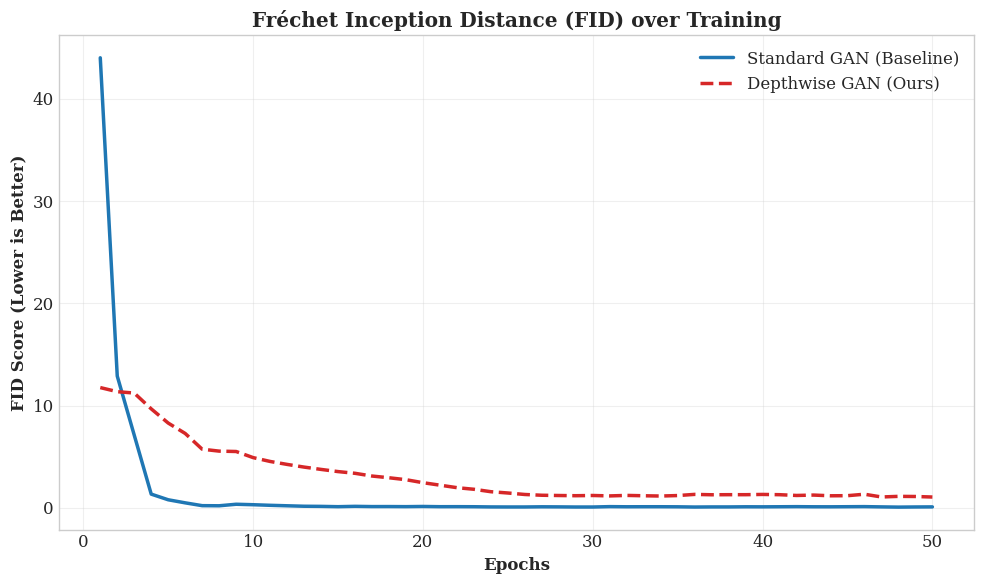

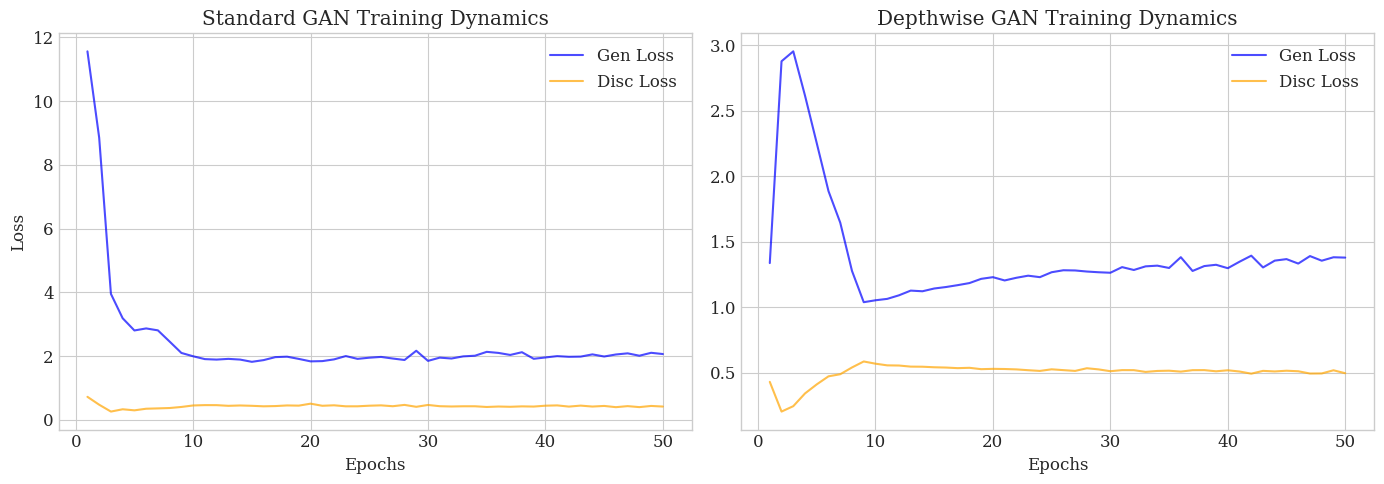

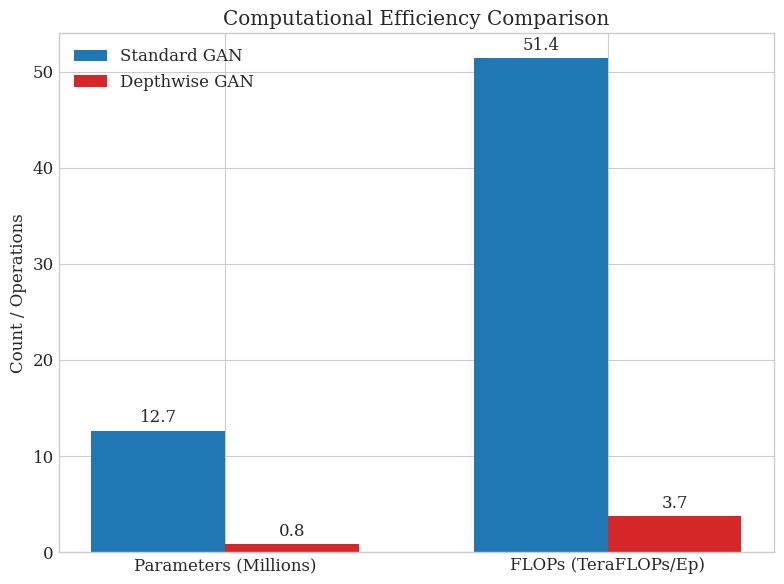

In [31]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

# Set style for academic paper plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

def load_metrics(path):
    if not os.path.exists(path):
        print(f"⚠️ Warning: Could not find {path}")
        return None
    with open(path, 'r') as f:
        return json.load(f)

def generate_paper_plots():
    # 1. Load Data
    std_data = load_metrics("checkpoints/training_metrics.json")
    dw_data = load_metrics("checkpoints/metrics_depthwise.json")

    if std_data is None or dw_data is None:
        print("Cannot generate plots: Missing JSON log files.")
        return

    # Extract Epochs and FID
    epochs_std = [e['epoch'] for e in std_data['epochs']]
    fid_std = [e['fid_score'] for e in std_data['epochs']]
    
    epochs_dw = [e['epoch'] for e in dw_data['epochs']]
    fid_dw = [e['fid_score'] for e in dw_data['epochs']]

    
    # PLOT 1: FID Comparison Curve
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_std, fid_std, label='Standard GAN (Baseline)', color='#1f77b4', linewidth=2.5)
    plt.plot(epochs_dw, fid_dw, label='Depthwise GAN (Ours)', color='#d62728', linewidth=2.5, linestyle='--')
    
    plt.xlabel('Epochs', fontweight='bold')
    plt.ylabel('FID Score (Lower is Better)', fontweight='bold')
    plt.title('Fréchet Inception Distance (FID) over Training', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('paper_fid_comparison.png', dpi=300)
    print("✓ Saved paper_fid_comparison.png")

    
    # PLOT 2: Loss Dynamics (Generator vs Discriminator)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Standard Losses
    g_loss_std = [e['loss_gen'] for e in std_data['epochs']]
    d_loss_std = [e['loss_disc'] for e in std_data['epochs']]
    ax1.plot(epochs_std, g_loss_std, label='Gen Loss', color='blue', alpha=0.7)
    ax1.plot(epochs_std, d_loss_std, label='Disc Loss', color='orange', alpha=0.7)
    ax1.set_title("Standard GAN Training Dynamics")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    
    # Depthwise Losses
    g_loss_dw = [e['loss_gen'] for e in dw_data['epochs']]
    d_loss_dw = [e['loss_disc'] for e in dw_data['epochs']]
    ax2.plot(epochs_dw, g_loss_dw, label='Gen Loss', color='blue', alpha=0.7)
    ax2.plot(epochs_dw, d_loss_dw, label='Disc Loss', color='orange', alpha=0.7)
    ax2.set_title("Depthwise GAN Training Dynamics")
    ax2.set_xlabel("Epochs")
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('paper_loss_curves.png', dpi=300)
    print("✓ Saved paper_loss_curves.png")

    
    # PLOT 3: Efficiency Comparison Bar Chart
    
    # Get stats from the log file headers
    std_params = std_data.get('model_stats', {}).get('gen_params', 3500000) # Fallback if missing
    dw_params = dw_data.get('model_stats', {}).get('gen_params', 500000)
    
    # Approx FLOPs (using your logs)
    std_flops = std_data.get('model_stats', {}).get('est_gen_flops_epoch_T', 51.0)
    dw_flops = dw_data.get('model_stats', {}).get('est_gen_flops_epoch_T', 3.7)

    labels = ['Parameters (Millions)', 'FLOPs (TeraFLOPs/Ep)']
    std_vals = [std_params / 1e6, std_flops]
    dw_vals = [dw_params / 1e6, dw_flops]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar(x - width/2, std_vals, width, label='Standard GAN', color='#1f77b4')
    rects2 = ax.bar(x + width/2, dw_vals, width, label='Depthwise GAN', color='#d62728')

    ax.set_ylabel('Count / Operations')
    ax.set_title('Computational Efficiency Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    # Add text labels on bars
    ax.bar_label(rects1, padding=3, fmt='%.1f')
    ax.bar_label(rects2, padding=3, fmt='%.1f')

    plt.tight_layout()
    plt.savefig('paper_efficiency_chart.png', dpi=300)
    print("✓ Saved paper_efficiency_chart.png")

if __name__ == "__main__":
    generate_paper_plots()

In [47]:
import os
import glob
from PIL import Image, ImageDraw, ImageFont


# CONFIGURATION

SOURCE_FOLDER = "outputs"
OUTPUT_PREFIX = "paper_visuals"

def get_epoch_from_filename(filename):
    """Robustly extracts epoch number from various filename formats."""
    try:
        base = os.path.basename(filename)
        parts = base.split('_')
        
        # Find the part that starts with "epoch" (e.g., epoch_01.png)
        # or implies epoch (e.g., depthwise_epoch_05...)
        if "epoch" in parts:
            idx = parts.index("epoch")
            epoch_part = parts[idx + 1] # This is usually "01.png" or "01"
            
            # Extract just the digits
            digits = ''.join(filter(str.isdigit, epoch_part.split('.')[0]))
            return int(digits)
    except:
        return -1
    return -1

def crop_top_row(img_path):
    """Crops the top row (5 digits) from the grid."""
    try:
        img = Image.open(img_path)
        w, h = img.size
        # Crop top 20% (assuming 5x5 grid)
        return img.crop((0, 0, w, h // 5))
    except Exception as e:
        print(f"Error cropping {img_path}: {e}")
        return None

def select_best_image_for_epoch(file_list):
    """
    Priority Logic:
    1. Prefer exact match like 'epoch_01.png' (shortest filename usually)
    2. Fallback to 'epoch_01_fid...'
    """
    if not file_list:
        return None
    
    # Sort by filename length. 
    # 'epoch_01.png' (len 12) is shorter than 'epoch_01_fid11.7.png' (len 20)
    # This automatically prioritizes the "clean" file.
    file_list.sort(key=lambda x: len(os.path.basename(x)))
    
    return file_list[0]

def create_timeline(grouped_files, title, output_filename):
    """Generates the timeline strip for every 3rd epoch."""
    
    # 1. Sort epochs
    epochs = sorted(grouped_files.keys())
    
    # 2. Filter: Keep 1, 4, 7... and always the last one
    selected_epochs = []
    for ep in epochs:
        if ep > 0 and (ep - 1) % 3 == 0:
            selected_epochs.append(ep)
            
    # Ensure the very last epoch is included for the finale
    if epochs and epochs[-1] not in selected_epochs:
        selected_epochs.append(epochs[-1])

    print(f"Generating {title} using epochs: {selected_epochs}")

    # 3. Build Strips
    strips = []
    for ep in selected_epochs:
        # Get the "cleanest" file for this epoch
        best_file = select_best_image_for_epoch(grouped_files[ep])
        
        strip = crop_top_row(best_file)
        if strip:
            strips.append((strip, f"Epoch {ep}"))

    if not strips:
        print(f"No valid images found for {title}")
        return None

    # 4. Draw Canvas
    w, h = strips[0][0].size
    padding = 30
    header_height = 60
    total_h = header_height + (h + padding) * len(strips)
    
    canvas = Image.new("RGB", (w, total_h), "white")
    draw = ImageDraw.Draw(canvas)
    
    try:
        font_header = ImageFont.truetype("arial.ttf", 28)
        font_label = ImageFont.truetype("arial.ttf", 18)
    except:
        font_header = ImageFont.load_default()
        font_label = ImageFont.load_default()

    draw.text((10, 15), title, fill="black", font=font_header)
    
    y = header_height
    for img, label in strips:
        draw.text((10, y - 25), label, fill="#444", font=font_label)
        canvas.paste(img, (0, y))
        y += h + padding

    save_path = f"{OUTPUT_PREFIX}_{output_filename}"
    canvas.save(save_path)
    print(f"✓ Saved: {save_path}")
    
    # Return the image of the last epoch for the comparison figure
    last_ep = selected_epochs[-1]
    return select_best_image_for_epoch(grouped_files[last_ep])

def create_comparison(std_file, dw_file):
    """Side-by-side comparison of the best epoch."""
    if not std_file or not dw_file:
        return

    img_std = crop_top_row(std_file)
    img_dw = crop_top_row(dw_file)

    if img_std.size != img_dw.size:
        img_dw = img_dw.resize(img_std.size)

    w, h = img_std.size
    gap = 20
    canvas = Image.new("RGB", (w * 2 + gap, h + 60), "white")
    draw = ImageDraw.Draw(canvas)
    
    try:
        font = ImageFont.truetype("arial.ttf", 24)
    except:
        font = ImageFont.load_default()

    canvas.paste(img_std, (0, 50))
    canvas.paste(img_dw, (w + gap, 50))

    draw.text((10, 10), "Standard DCGAN", fill="black", font=font)
    draw.text((w + gap + 10, 10), "Depthwise GAN", fill="black", font=font)

    canvas.save(f"{OUTPUT_PREFIX}_final_comparison.png")
    print(f"✓ Saved: {OUTPUT_PREFIX}_final_comparison.png")

def main():
    all_files = glob.glob(os.path.join(SOURCE_FOLDER, "*.png"))
    
    # Dictionaries to group files by epoch: { 1: ['file1', 'file2'], 2: [...] }
    std_groups = {}
    dw_groups = {}

    for f in all_files:
        filename = os.path.basename(f)
        ep = get_epoch_from_filename(filename)
        if ep == -1: continue

        if "depthwise" in filename.lower():
            if ep not in dw_groups: dw_groups[ep] = []
            dw_groups[ep].append(f)
        elif filename.startswith("epoch_"):
            if ep not in std_groups: std_groups[ep] = []
            std_groups[ep].append(f)

    # Generate Timelines
    last_std_file = create_timeline(std_groups, "Standard GAN Timeline", "timeline_conv.png")
    last_dw_file = create_timeline(dw_groups, "Depthwise GAN Timeline", "timeline_depthwise.png")

    # Generate Final Comparison
    if last_std_file and last_dw_file:
        create_comparison(last_std_file, last_dw_file)

if __name__ == "__main__":
    main()

Generating Standard GAN Timeline using epochs: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49, 50]
✓ Saved: paper_visuals_timeline_conv.png
Generating Depthwise GAN Timeline using epochs: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49, 50]
✓ Saved: paper_visuals_timeline_depthwise.png
✓ Saved: paper_visuals_final_comparison.png


In [5]:
import shutil
import os

# usage: make_archive(output_filename, format, folder_to_zip)
shutil.make_archive("my_checkpoints_archive", 'zip', "checkpoints")

print("✅ Zipping complete! Look for 'my_checkpoints_archive.zip' in the Output section.")

✅ Zipping complete! Look for 'my_checkpoints_archive.zip' in the Output section.
